In [74]:
import torch
print(torch.cuda.is_available())

True


In [75]:
from google.colab import files
files.upload()

Saving amazon_cells_labelled.txt to amazon_cells_labelled (1).txt
Saving amazon_cells_labelled_LARGE_25K.txt to amazon_cells_labelled_LARGE_25K (1).txt


{'amazon_cells_labelled (1).txt': b'So there is no way for me to plug it in here in the US unless I go by a converter.\t0\nGood case, Excellent value.\t1\nGreat for the jawbone.\t1\nTied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!\t0\nThe mic is great.\t1\nI have to jiggle the plug to get it to line up right to get decent volume.\t0\nIf you have several dozen or several hundred contacts, then imagine the fun of sending each of them one by one.\t0\nIf you are Razr owner...you must have this!\t1\nNeedless to say, I wasted my money.\t0\nWhat a waste of money and time!.\t0\nAnd the sound quality is great.\t1\nHe was very impressed when going from the original battery to the extended battery.\t1\nIf the two were seperated by a mere 5+ ft I started to notice excessive static and garbled sound from the headset.\t0\nVery good quality though\t1\nThe design is very odd, as the ear "clip" is not very comfortable at all.\t0\nHighly recommend for any one who has a blu

In [76]:
## Getting an error so need to import these first
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [136]:
## Data loading .py
## Ignoring the warnings on the characters
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from matplotlib import pyplot
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk import word_tokenize
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report

def preprocess_pandas(data, columns):
    df_ = pd.DataFrame(columns=columns)
    data['Sentence'] = data['Sentence'].str.lower()
    data['Sentence'] = data['Sentence'].replace('[a-zA-Z0-9-_.]+@[a-zA-Z0-9-_.]+', '', regex=True)                      # remove emails
    data['Sentence'] = data['Sentence'].replace('((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', regex=True)    # remove IP address
    data['Sentence'] = data['Sentence'].str.replace('[^\w\s]','')                                                       # remove special characters
    data['Sentence'] = data['Sentence'].replace('\d', '', regex=True)                                                   # remove numbers
    for index, row in data.iterrows():
        word_tokens = word_tokenize(row['Sentence'])
        filtered_sent = [w for w in word_tokens if not w in stopwords.words('english')]
        df_.loc[len(df_)] = {
            "index": row['index'],
            "Class": row['Class'],
            "Sentence": " ".join(filtered_sent)
        }
    return data

# If this is the primary file that is executed (ie not an import of another file)
if __name__ == "__main__":
    # get data, pre-process and split
    data = pd.read_csv("amazon_cells_labelled.txt", delimiter='\t', header=None)
    data.columns = ['Sentence', 'Class']
    data['index'] = data.index                                          # add new column index
    columns = ['index', 'Class', 'Sentence']
    data = preprocess_pandas(data, columns)                             # pre-process
    training_data, validation_data, training_labels, validation_labels = train_test_split( # split the data into training, validation, and test splits
        data['Sentence'].values.astype('U'),
        data['Class'].values.astype('int32'),
        test_size=0.10,
        random_state=0,
        shuffle=True
    )

    # vectorize data using TFIDF and transform for PyTorch for scalability
    word_vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=50000, max_df=0.5, use_idf=True, norm='l2')
    training_data = word_vectorizer.fit_transform(training_data)        # transform texts to sparse matrix
    training_data = training_data.todense()                             # convert to dense matrix for Pytorch
    vocab_size = len(word_vectorizer.vocabulary_)
    validation_data = word_vectorizer.transform(validation_data)
    validation_data = validation_data.todense()
    train_x_tensor = torch.from_numpy(np.array(training_data)).type(torch.FloatTensor)
    train_y_tensor = torch.from_numpy(np.array(training_labels)).long()
    validation_x_tensor = torch.from_numpy(np.array(validation_data)).type(torch.FloatTensor)
    validation_y_tensor = torch.from_numpy(np.array(validation_labels)).long()


<>:21: SyntaxWarning: invalid escape sequence '\.'
<>:22: SyntaxWarning: invalid escape sequence '\w'
<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\.'
<>:22: SyntaxWarning: invalid escape sequence '\w'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11792/2458183006.py:21: SyntaxWarning: invalid escape sequence '\.'
  data['Sentence'] = data['Sentence'].replace('((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', regex=True)    # remove IP address
/tmp/ipykernel_11792/2458183006.py:22: SyntaxWarning: invalid escape sequence '\w'
  data['Sentence'] = data['Sentence'].str.replace('[^\w\s]','')                                                       # remove special characters
/tmp/ipykernel_11792/2458183006.py:23: SyntaxWarning: invalid escape sequence '\d'
  data['Sentence'] = data['Sentence'].replace('\d', '', regex=True)                                                   # remove numbers


In [78]:
## Checking if everthing is loaded correctly
print(f"Training samples: {train_x_tensor.shape}")
print(f"Validation samples: {validation_x_tensor.shape}")
print(f"Vocab size: {vocab_size}")

Training samples: torch.Size([900, 7277])
Validation samples: torch.Size([100, 7277])
Vocab size: 7277


In [79]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [143]:
## very basic ANNs, a bit of tuning included with small dataset.
model_64 = nn.Sequential(
    nn.Linear(vocab_size, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 2)
).to(device)

model_128 = nn.Sequential(
    nn.Linear(vocab_size, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
).to(device)

## Found that it was overfitting with 900 data
# model_256 = nn.Sequential(
#     nn.Linear(vocab_size, 256),
#     nn.ReLU(),
#     nn.Dropout(0.3),
#     nn.Linear(256, 2)
# ).to(device)


In [142]:
## Train function
def train_model(model, train_x, train_y, val_x, val_y, epochs=50, lr=0.001, batch_size=32):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) ## worked fine in lab0.
    train_loss_history = []
    val_loss_history = []

    train_dataset = TensorDataset(train_x, train_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x.to(device)) ##
            loss = criterion(outputs, batch_y.to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        avg_train_loss = epoch_loss / len(train_loader)
        # train_loss_history.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
                    val_outputs = model(val_x.to(device))
                    val_loss = criterion(val_outputs, val_y.to(device))
                    val_loss_history.append(val_loss.item())

                    train_outputs = model(train_x.to(device))
                    train_eval_loss = criterion(train_outputs, train_y.to(device))
                    train_loss_history.append(train_eval_loss.item())

        if (epoch+1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_eval_loss.item():.4f} - Val Loss: {val_loss.item():.4f}")

    return train_loss_history, val_loss_history

In [144]:
print("Training model_64:")
train_h64, val_h64 = train_model(model_64, train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor)

print("\nTraining model_128:")
train_h128, val_h128 = train_model(model_128, train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor)

# print("\nTraining model_256:")
# train_h256, val_h256 = train_model(model_256, train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor)

Training model_64:
Epoch 5/50 - Train Loss: 0.2389 - Val Loss: 0.4255
Epoch 10/50 - Train Loss: 0.0381 - Val Loss: 0.3254
Epoch 15/50 - Train Loss: 0.0132 - Val Loss: 0.3183
Epoch 20/50 - Train Loss: 0.0063 - Val Loss: 0.3171
Epoch 25/50 - Train Loss: 0.0037 - Val Loss: 0.3231
Epoch 30/50 - Train Loss: 0.0023 - Val Loss: 0.3204
Epoch 35/50 - Train Loss: 0.0016 - Val Loss: 0.3251
Epoch 40/50 - Train Loss: 0.0011 - Val Loss: 0.3288
Epoch 45/50 - Train Loss: 0.0008 - Val Loss: 0.3365
Epoch 50/50 - Train Loss: 0.0006 - Val Loss: 0.3369

Training model_128:
Epoch 5/50 - Train Loss: 0.1148 - Val Loss: 0.3480
Epoch 10/50 - Train Loss: 0.0150 - Val Loss: 0.2997
Epoch 15/50 - Train Loss: 0.0054 - Val Loss: 0.3009
Epoch 20/50 - Train Loss: 0.0026 - Val Loss: 0.3043
Epoch 25/50 - Train Loss: 0.0015 - Val Loss: 0.3115
Epoch 30/50 - Train Loss: 0.0010 - Val Loss: 0.3178
Epoch 35/50 - Train Loss: 0.0007 - Val Loss: 0.3197
Epoch 40/50 - Train Loss: 0.0005 - Val Loss: 0.3245
Epoch 45/50 - Train Loss: 

In [145]:
##eval funtion
def evaluate_model(model, val_x, val_y):
    model.eval()
    with torch.no_grad():
        outputs = model(val_x.to(device))
        predictions = torch.argmax(outputs, dim=1).cpu().numpy() ## this required to convert gpu to cpu
        true_labels = val_y.numpy()
    print(classification_report(true_labels, predictions))
    return predictions

Model 64:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        47
           1       0.89      0.77      0.83        53

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100

Model 128:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87        47
           1       0.90      0.85      0.87        53

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



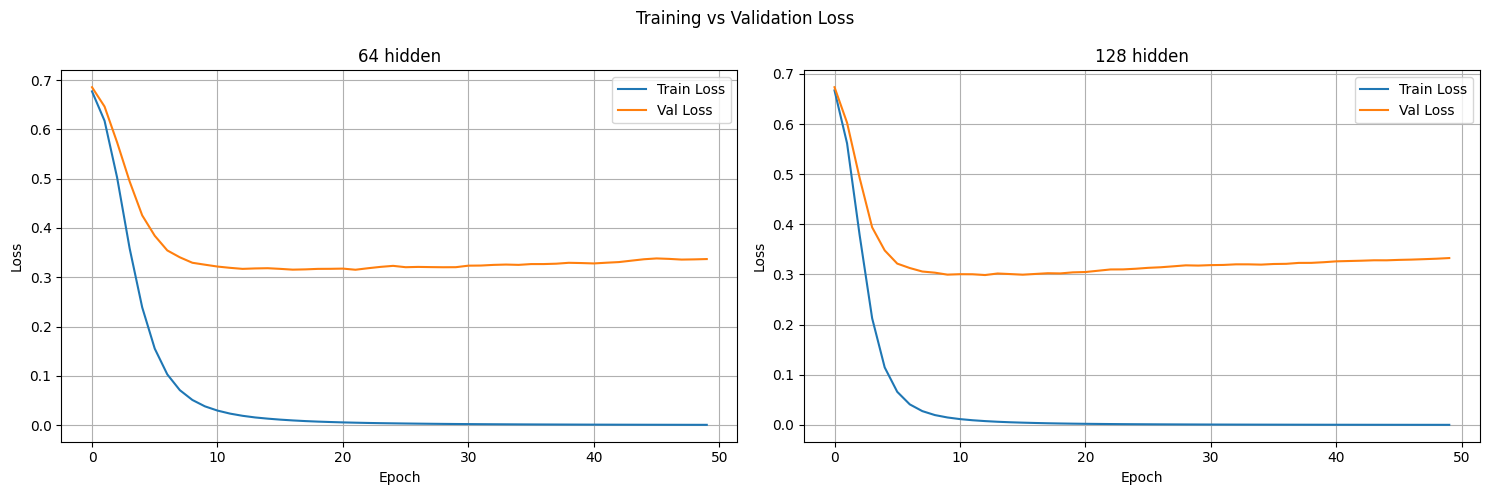

In [146]:
## Overfits currenlty but F1 score seems okay so maybe feeding more data would work
print("Model 64:")
preds_64 = evaluate_model(model_64, validation_x_tensor, validation_y_tensor)

print("Model 128:")
preds_128 = evaluate_model(model_128, validation_x_tensor, validation_y_tensor)

# print("Model 256:")
# preds_256 = evaluate_model(model_256, validation_x_tensor, validation_y_tensor)

fig, axes = pyplot.subplots(1, 2, figsize=(15, 5))

for ax, train_h, val_h, name in zip(axes,
                                     [train_h64, train_h128],
                                     [val_h64, val_h128],
                                     ['64 hidden', '128 hidden']):
    ax.plot(train_h, label='Train Loss')
    ax.plot(val_h, label='Val Loss')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

pyplot.suptitle('Training vs Validation Loss')
pyplot.tight_layout()
pyplot.show()

In [154]:
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils.rnn import pack_padded_sequence
word2idx = {'<PAD>': 0, '<UNK>': 1}
for sentence in data['Sentence']:
    for word in sentence.split():
        if word not in word2idx:
            word2idx[word] = len(word2idx)

X_lstm = torch.tensor([[word2idx.get(w, 1) for w in s.split()][:50] +
                        [0] * max(0, 50 - len(s.split()))
                        for s in data['Sentence']], dtype=torch.long)
y_lstm = torch.tensor(data['Class'].values, dtype=torch.long)

X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.10, random_state=0, shuffle=True)

print(f"Vocab size: {len(word2idx)}")
print(f"X_train_lstm shape: {X_train_lstm.shape}")

Vocab size: 2470
X_train_lstm shape: torch.Size([900, 50])


In [157]:
## not a big fan of classes here but could not find a good example for LSTM
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.5) # that worked fine at the prev. step
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lengths = (x != 0).sum(dim=1).cpu()
        x = self.embedding(x)
        x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(x)
        x = self.dropout(hidden[-1])
        x = self.fc(x)
        return x

lstm_model = LSTMModel(vocab_size=len(word2idx), embed_dim=32, hidden_dim=128, output_dim=2).to(device)
## reduced embedded dimension slightly
print("Training LSTM:")
train_h_lstm, val_h_lstm = train_model(lstm_model, X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, lr=0.001,epochs=7)

Training LSTM:
Epoch 5/7 - Train Loss: 0.4390 - Val Loss: 0.4431


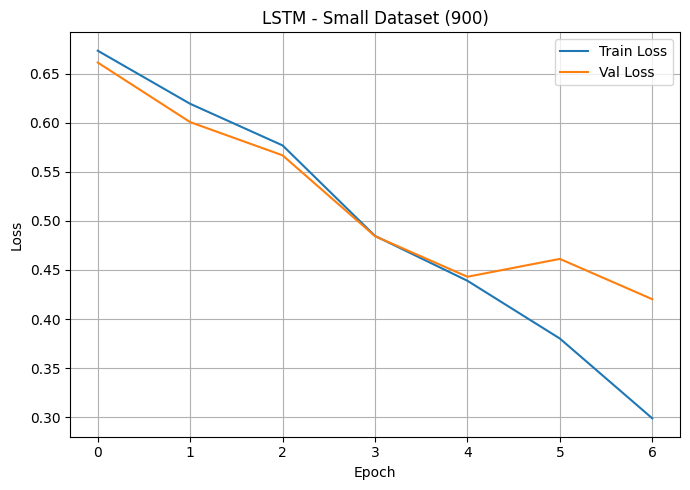

In [158]:
## cut epoch at 7, did not define a smart stop algorthim.
fig, axes = pyplot.subplots(1, 1, figsize=(7, 5))
axes.plot(train_h_lstm, label='Train Loss')
axes.plot(val_h_lstm, label='Val Loss')
axes.set_title('LSTM - Small Dataset (900)')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.legend()
axes.grid(True)
pyplot.tight_layout()
pyplot.show()

In [185]:
# Feeding more data to test previous steps, 5k. This was initial test.
## Noticed that LTSM improved so decided to increase the sample size
if __name__ == "__main__":
    # get data, pre-process and split
    data = pd.read_csv("amazon_cells_labelled_LARGE_25K.txt", delimiter='\t', header=None)
    data.columns = ['Sentence', 'Class']
    data = data.sample(n=10000, random_state=0).reset_index(drop=True) ##
    data['index'] = data.index                                          # add new column index
    columns = ['index', 'Class', 'Sentence']
    data = preprocess_pandas(data, columns)                             # pre-process
    training_data, validation_data, training_labels, validation_labels = train_test_split( # split the data into training, validation, and test splits
        data['Sentence'].values.astype('U'),
        data['Class'].values.astype('int32'),
        test_size=0.10,
        random_state=0,
        shuffle=True
    )

    # vectorize data using TFIDF and transform for PyTorch for scalability
    word_vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=50000, max_df=0.5, use_idf=True, norm='l2')
    training_data = word_vectorizer.fit_transform(training_data)        # transform texts to sparse matrix
    training_data = training_data.todense()                             # convert to dense matrix for Pytorch
    vocab_size = len(word_vectorizer.vocabulary_)
    validation_data = word_vectorizer.transform(validation_data)
    validation_data = validation_data.todense()
    train_x_tensor = torch.from_numpy(np.array(training_data)).type(torch.FloatTensor)
    train_y_tensor = torch.from_numpy(np.array(training_labels)).long()
    validation_x_tensor = torch.from_numpy(np.array(validation_data)).type(torch.FloatTensor)
    validation_y_tensor = torch.from_numpy(np.array(validation_labels)).long()

In [186]:
## Checking again if everthing is loaded correctly
print(f"Training samples: {train_x_tensor.shape}")
print(f"Validation samples: {validation_x_tensor.shape}")
print(f"Vocab size: {vocab_size}")

Training samples: torch.Size([9000, 50000])
Validation samples: torch.Size([1000, 50000])
Vocab size: 50000


In [161]:
model_64 = nn.Sequential(
    nn.Linear(vocab_size, 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 2)
).to(device)

model_128 = nn.Sequential(
    nn.Linear(vocab_size, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
).to(device)

In [162]:
print("Training model_64:")
train_h64_2, val_h64_2 = train_model(model_64, train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor,epochs=5) ## 5k

print("\nTraining model_128:")
train_h128_2, val_h128_2  = train_model(model_128, train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor,epochs=5) ## 5k


Training model_64:
Epoch 5/5 - Train Loss: 0.0099 - Val Loss: 0.3293

Training model_128:
Epoch 5/5 - Train Loss: 0.0040 - Val Loss: 0.3424


In [163]:
print("Model 64:")
preds_64_2 = evaluate_model(model_64, validation_x_tensor, validation_y_tensor)

print("Model 128:")
preds_128_2 = evaluate_model(model_128, validation_x_tensor, validation_y_tensor)

Model 64:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       198
           1       0.87      0.93      0.90       302

    accuracy                           0.87       500
   macro avg       0.88      0.86      0.86       500
weighted avg       0.87      0.87      0.87       500

Model 128:
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       198
           1       0.87      0.94      0.90       302

    accuracy                           0.88       500
   macro avg       0.88      0.87      0.87       500
weighted avg       0.88      0.88      0.88       500



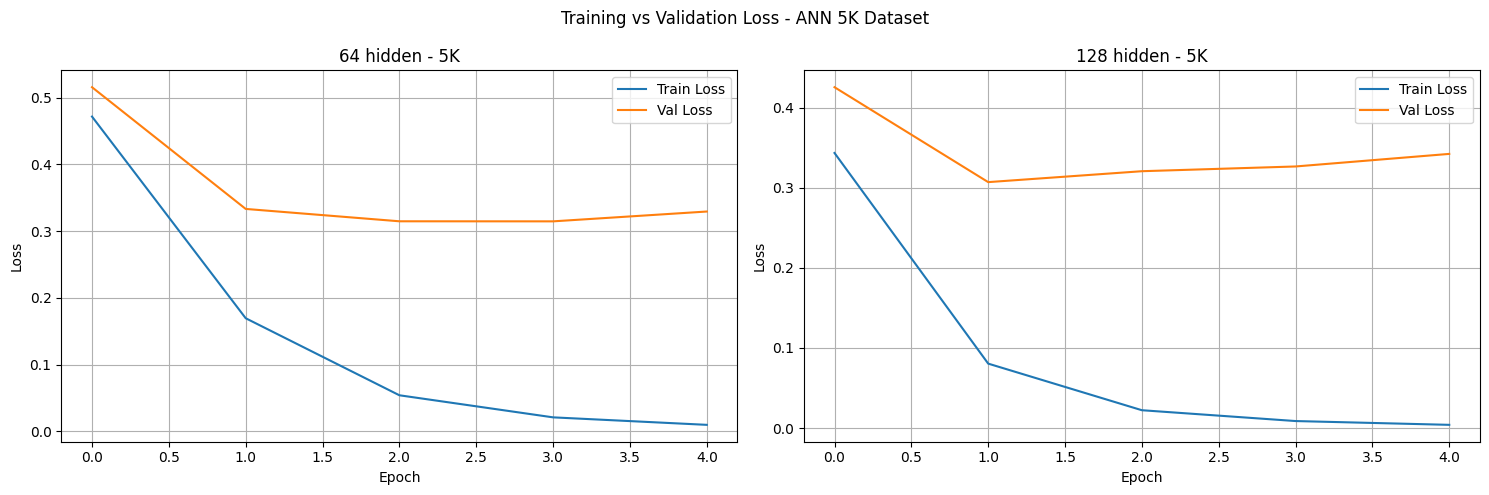

In [164]:
## okay looks like 5k improves the results slighlty, reduced epoch no too.
fig, axes = pyplot.subplots(1, 2, figsize=(15, 5))

for ax, train_h, val_h, name in zip(axes,
                                     [train_h64_2, train_h128_2],
                                     [val_h64_2, val_h128_2],
                                     ['64 hidden - 5K', '128 hidden - 5K']):
    ax.plot(train_h, label='Train Loss')
    ax.plot(val_h, label='Val Loss')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

pyplot.suptitle('Training vs Validation Loss - ANN 5K Dataset')
pyplot.tight_layout()
pyplot.show()

In [187]:
## rebuilding vocab
word2idx = {'<PAD>': 0, '<UNK>': 1}
for sentence in data['Sentence']:
    for word in sentence.split():
        if word not in word2idx:
            word2idx[word] = len(word2idx)

X_lstm = torch.tensor([[word2idx.get(w, 1) for w in s.split()][:50] +
                        [0] * max(0, 50 - len(s.split()))
                        for s in data['Sentence']], dtype=torch.long)
y_lstm = torch.tensor(data['Class'].values, dtype=torch.long)

X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.10, random_state=0, shuffle=True)

print(f"Vocab size: {len(word2idx)}")
print(f"X_train_lstm shape: {X_train_lstm.shape}")

Vocab size: 22112
X_train_lstm shape: torch.Size([9000, 50])


In [188]:
## Initially tried this with 5k, and 10k. However the overfitting did not resolve.
## better than 900 samples though. To discuss with the group.
lstm_model = LSTMModel(vocab_size=len(word2idx), embed_dim=64, hidden_dim=128, output_dim=2).to(device)

print("Training LSTM - 5K:")
train_h_lstm_5k, val_h_lstm_5k = train_model(lstm_model, X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, lr=0.001,epochs=6)
print("\nLSTM 5K Evaluation:")
preds_lstm_5k = evaluate_model(lstm_model, X_val_lstm, y_val_lstm)

Training LSTM - 5K:
Epoch 5/6 - Train Loss: 0.1037 - Val Loss: 0.4914

LSTM 5K Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76       370
           1       0.87      0.82      0.85       630

    accuracy                           0.81      1000
   macro avg       0.80      0.81      0.80      1000
weighted avg       0.82      0.81      0.81      1000



The title here suggests with 5k input data but actually 10k. I wanted to quickly test if anything gets improved with more data on this model. Results are more or less the same with 5k input. Check the end summary table for an overivew on the evaluation matrix.

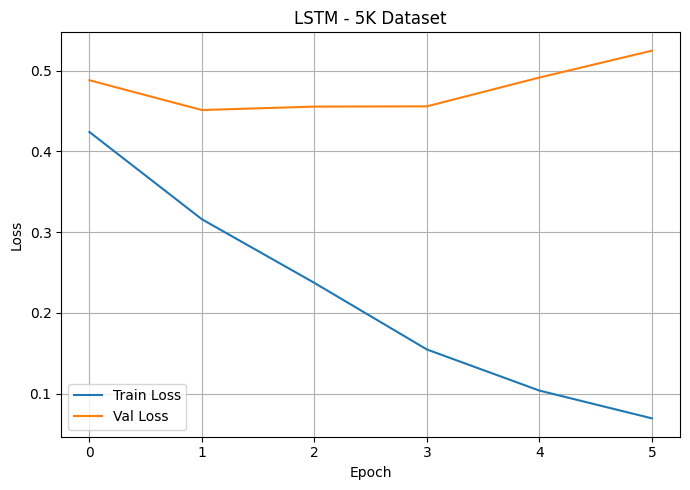

In [189]:
fig, axes = pyplot.subplots(1, 1, figsize=(7, 5))
axes.plot(train_h_lstm_5k, label='Train Loss')
axes.plot(val_h_lstm_5k, label='Val Loss')
axes.set_title('LSTM - 5K Dataset')
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.legend()
axes.grid(True)
pyplot.tight_layout()
pyplot.show()

In [191]:
## Cleaning up the code a bit
lstm_model = LSTMModel(vocab_size=len(word2idx), embed_dim=64, hidden_dim=128, output_dim=2).to(device)

print("Training LSTM - 10K:")
train_h_lstm_10k, val_h_lstm_10k = train_model(lstm_model, X_train_lstm, y_train_lstm, X_val_lstm, y_val_lstm, epochs=2)

print("\nLSTM 10K Evaluation:")
preds_lstm_10k = evaluate_model(lstm_model, X_val_lstm, y_val_lstm)



Training LSTM - 10K:

LSTM 10K Evaluation:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       370
           1       0.83      0.87      0.85       630

    accuracy                           0.80      1000
   macro avg       0.79      0.78      0.78      1000
weighted avg       0.80      0.80      0.80      1000



In [192]:
## Overall evaluation summary is below

## Results Summary - Task 1.1
results = {
    'Model': ['ANN 64', 'ANN 128', 'ANN 64', 'ANN 128', 'LSTM', 'LSTM', 'LSTM'],
    'Dataset': ['1K', '1K', '5K', '5K', '1K', '5K', '10K'],
    'Accuracy': [0.82, 0.84, 0.87, 0.88, 'unstable', 0.81, 0.80],
    'F1': [0.82, 0.84, 0.86, 0.88, '—', 0.80, 0.80]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

  Model Dataset Accuracy    F1
 ANN 64      1K     0.82  0.82
ANN 128      1K     0.84  0.84
 ANN 64      5K     0.87  0.86
ANN 128      5K     0.88  0.88
   LSTM      1K unstable     —
   LSTM      5K     0.81   0.8
   LSTM     10K      0.8   0.8


Task 1.2

In [193]:
!pip install transformers datasets -q

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import numpy as np

In [194]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
transformer_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully


In [195]:
train_dict = {'text': list(data['Sentence'][data.index.isin(pd.Series(range(len(data))).sample(frac=0.9, random_state=0))]),
              'label': list(data['Class'][data.index.isin(pd.Series(range(len(data))).sample(frac=0.9, random_state=0))])}

## Simpler approach
texts = data['Sentence'].tolist()
labels = data['Class'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.10, random_state=0, shuffle=True)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
val_dataset = Dataset.from_dict({'text': val_texts, 'label': val_labels})

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

Train size: 9000
Val size: 1000


In [196]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

print("Tokenisation complete")

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenisation complete


In [198]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    report_to='none'
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.213385,0.222783
2,0.168465,0.176451
3,0.115174,0.195719


TrainOutput(global_step=846, training_loss=0.2144257526307523, metrics={'train_runtime': 281.9269, 'train_samples_per_second': 95.77, 'train_steps_per_second': 3.001, 'total_flos': 894154940928000.0, 'train_loss': 0.2144257526307523, 'epoch': 3.0})

In [199]:
## Evaluate transformer
predictions = trainer.predict(val_dataset)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       370
           1       0.93      0.96      0.95       630

    accuracy                           0.93      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.93      0.93      0.93      1000



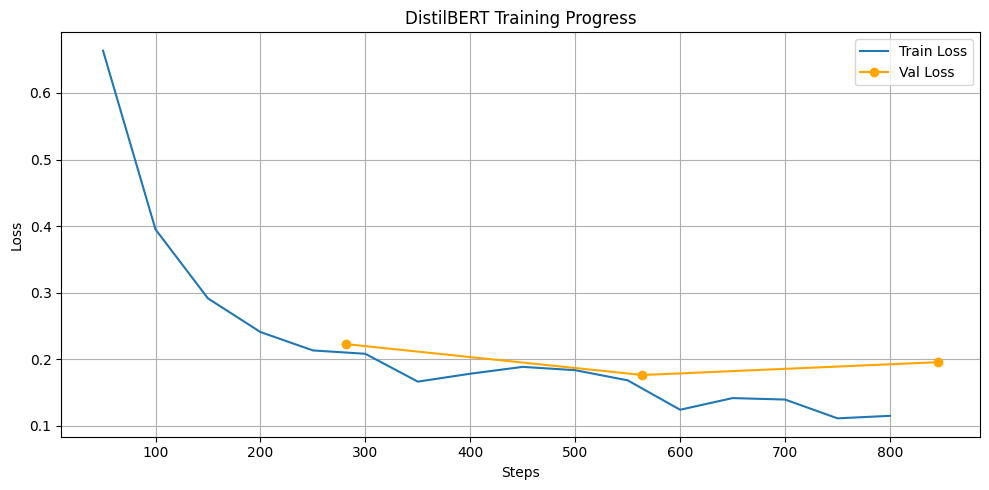

In [201]:
train_losses = [x['loss'] for x in training_logs if 'loss' in x]
steps = [x['step'] for x in training_logs if 'loss' in x]
eval_losses = [x['eval_loss'] for x in training_logs if 'eval_loss' in x]
eval_steps = [x['step'] for x in training_logs if 'eval_loss' in x]

fig, ax = pyplot.subplots(figsize=(10, 5))
ax.plot(steps, train_losses, label='Train Loss')
ax.plot(eval_steps, eval_losses, label='Val Loss', color='orange', marker='o')
ax.set_title('DistilBERT Training Progress')
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
pyplot.tight_layout()
pyplot.show()

## Task 1.3 - Model Comparison

### Performance Summary

| Model | Dataset | Accuracy | F1 |
|---|---|---|---|
| ANN 64 | 1K | 0.82 | 0.82 |
| ANN 128 | 1K | 0.84 | 0.84 |
| ANN 64 | 5K | 0.87 | 0.86 |
| ANN 128 | 5K | 0.88 | 0.88 |
| LSTM | 1K | unstable | — |
| LSTM | 5K | 0.81 | 0.80 |
| LSTM | 10K | 0.80 | 0.80 |
| DistilBERT | 10K | 0.93 | 0.93 |

The simple ANN with TF-IDF outperformed the LSTM across all dataset sizes. Both custom 
models suffered from severe overfitting regardless of dataset size or architectural tuning 
— only DistilBERT's pretrained contextual embeddings provided stable generalisation, 
achieving 0.93 accuracy and confirming that transfer learning is the most effective 
approach when labelled data is limited.

In summary, training data size does impact generalisation and performance, however the 
custom models were too simplistic to overcome overfitting — even increasing the dataset 
size yielded only minor improvements in accuracy and F1 (ANN).